# API Data Wrangling with Open-Meteo

In this exercise, we will:

- Fetch historical weather data using the **Open-Meteo API**.
- Parse and clean the data using **pandas**.
- Perform exploratory data analysis.
- Visualize weather trends.

In [2]:
# Install required packages if not already installed
# !pip install requests pandas matplotlib --quiet

In [2]:
# Import Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Configure matplotlib for inline display in Jupyter
%matplotlib inline

## Understand the Open-Meteo API

- **API Endpoint**: `https://archive-api.open-meteo.com/v1/archive`
- **Parameters**:
  - `latitude`: Latitude of the location.
  - `longitude`: Longitude of the location.
  - `start_date`: Start date of the data (YYYY-MM-DD).
  - `end_date`: End date of the data (YYYY-MM-DD).
  - `hourly`: Comma-separated list of variables (e.g., temperature, precipitation).
  - `timezone`: Timezone of the data.

**Documentation**: [Open-Meteo API Docs](https://open-meteo.com/en/docs)

In [3]:
# Step 1: Set Up Parameters

# Location coordinates for New York City
latitude = 40.7128
longitude = -74.0060

# Date range
start_date = '2023-01-01'
end_date = '2023-01-07'  # One week of data

# Variables to fetch
hourly_variables = ['temperature_2m', 'relativehumidity_2m', 'precipitation']


In [4]:
# Step 2: Make the API Request

base_url = 'https://archive-api.open-meteo.com/v1/archive'

params = {
    'latitude': latitude,
    'longitude': longitude,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/New_York'
}

response = requests.get(base_url, params=params)


In [5]:
# Check if the request was successful

if response.status_code == 200:
    print('Data fetched successfully!')
else:
    print(f'Failed to fetch data. Status code: {response.status_code}')


Data fetched successfully!


In [24]:
# Step 3: Load Data into pandas DataFrame
print(response)
data = response.json()
hourly_data = data['hourly']

df = pd.DataFrame(hourly_data)
df.head()

<Response [200]>


,time,temperature_2m,relativehumidity_2m,precipitation
0,2023-01-01T00:00,10.9,99,1.0
1,2023-01-01T01:00,10.6,99,1.0
2,2023-01-01T02:00,10.6,98,0.1
3,2023-01-01T03:00,10.5,96,0.0
4,2023-01-01T04:00,9.8,95,0.0


In [25]:
# Step 4: Data Cleaning

# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])

# Set 'time' as the index
df.set_index('time', inplace=True)

# Check for missing values
df.isnull().sum()


temperature_2m         0
relativehumidity_2m    0
precipitation          0
dtype: int64

In [ ]:
# Handle missing values (if any)
df.fillna(method='ffill', inplace=True)  # Forward fill


In [28]:
# Step 5: Exploratory Data Analysis

# Summary Statistics
df.describe()

,temperature_2m,relativehumidity_2m,precipitation
count,168.000000,168.000000,168.000000
mean,8.527976,86.422619,0.142857
std,3.496533,12.799933,0.436037
min,0.500000,45.000000,0.000000
25%,6.100000,81.000000,0.000000
50%,8.400000,90.500000,0.000000
75%,11.300000,97.000000,0.000000
max,18.000000,100.000000,3.100000


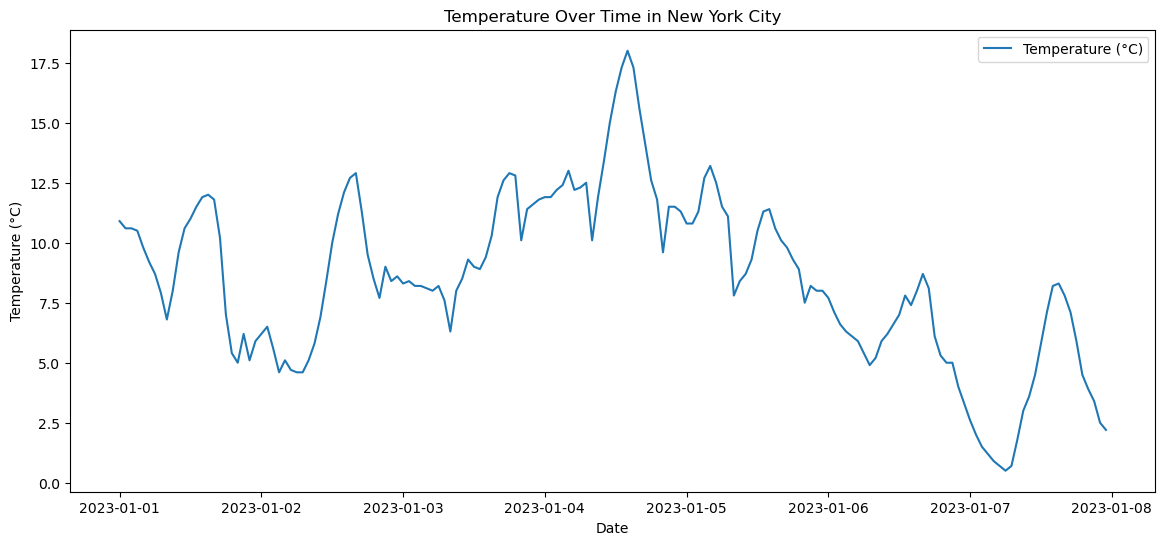

In [29]:
# Plot Temperature Over Time

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['temperature_2m'], label='Temperature (°C)')
plt.title('Temperature Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

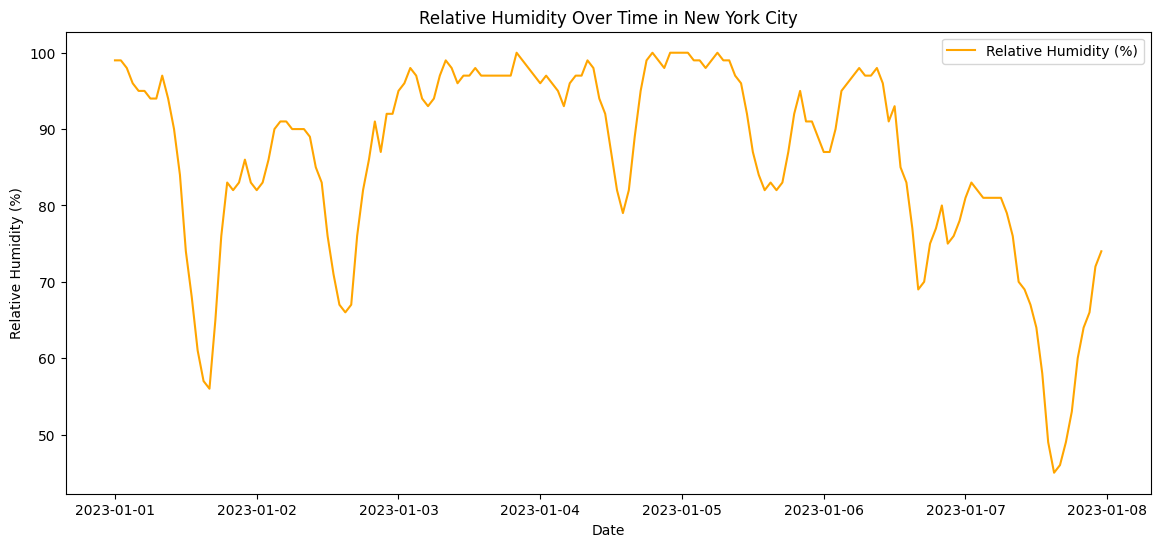

In [12]:
# Plot Relative Humidity Over Time

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['relativehumidity_2m'], color='orange', label='Relative Humidity (%)')
plt.title('Relative Humidity Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Relative Humidity (%)')
plt.legend()
plt.show()


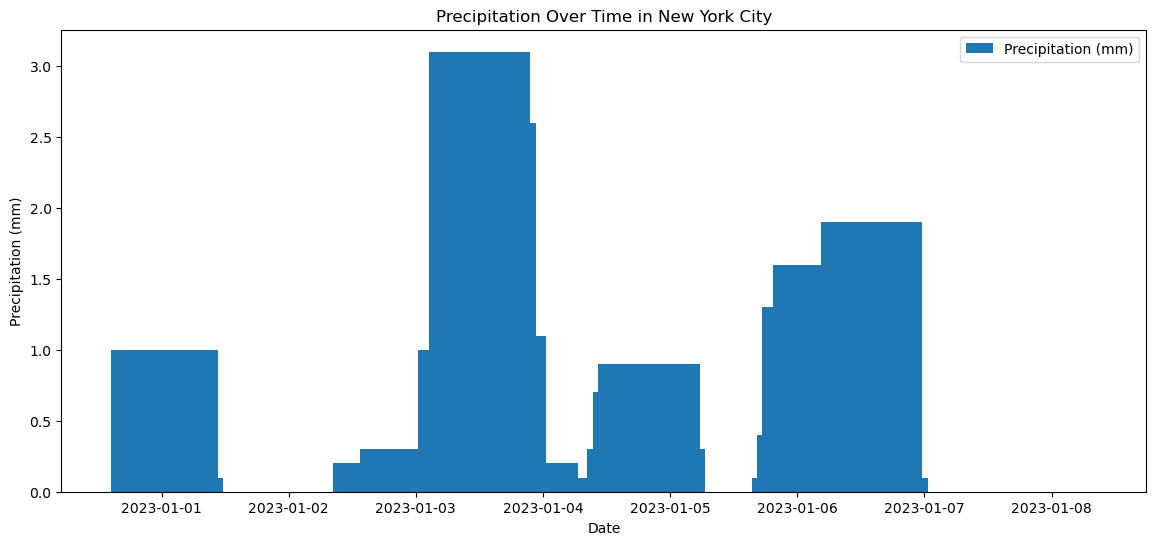

In [30]:
# Plot Precipitation Over Time

plt.figure(figsize=(14, 6))
plt.bar(df.index, df['precipitation'], label='Precipitation (mm)')
plt.title('Precipitation Over Time in New York City')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.legend()
plt.show()


In [14]:
# Step 6: Correlation Analysis

# Calculate correlation between temperature and humidity
correlation = df['temperature_2m'].corr(df['relativehumidity_2m'])
print(f'Correlation between Temperature and Relative Humidity: {correlation:.2f}')


Correlation between Temperature and Relative Humidity: 0.24


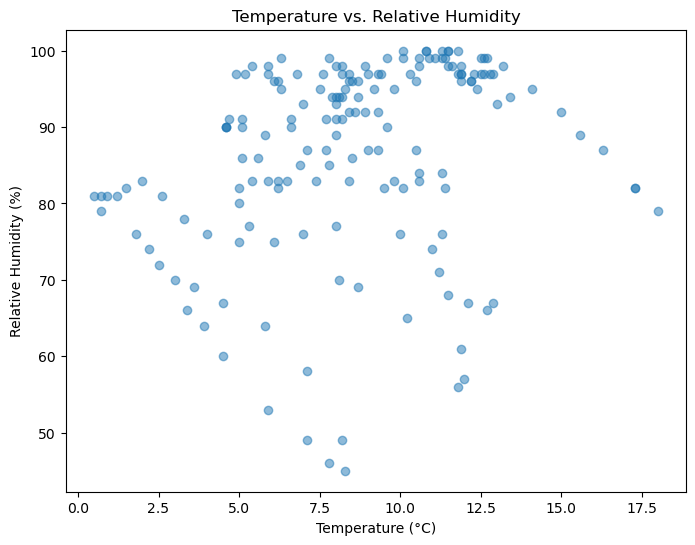

In [31]:
# Scatter Plot of Temperature vs. Relative Humidity

plt.figure(figsize=(8, 6))
plt.scatter(df['temperature_2m'], df['relativehumidity_2m'], alpha=0.5)
plt.title('Temperature vs. Relative Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()


In [32]:
# Step 7: Resample Data to Daily Averages

daily_avg = df.resample('D').mean()
daily_avg.head()


,temperature_2m,relativehumidity_2m,precipitation
time,,,
2023-01-01,9.008333,83.708333,0.087500
2023-01-02,7.916667,83.458333,0.020833
2023-01-03,9.575000,96.875000,0.395833
2023-01-04,13.154167,94.166667,0.095833
2023-01-05,10.070833,92.666667,0.000000


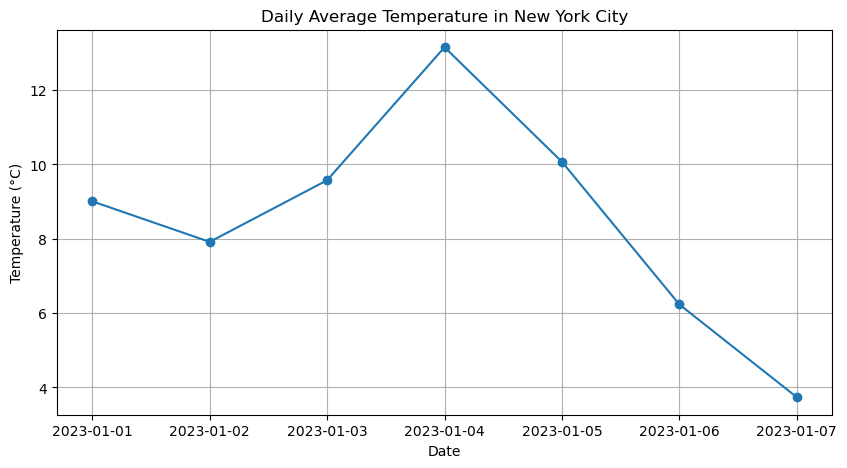

In [33]:
# Plot Daily Average Temperature

plt.figure(figsize=(10, 5))
plt.plot(daily_avg.index, daily_avg['temperature_2m'], marker='o')
plt.title('Daily Average Temperature in New York City')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()


In [ ]:
# Step 8: Compare with Another Location (Los Angeles)

# Coordinates for Los Angeles
latitude_la = 34.0522
longitude_la = -118.2437

params_la = {
    'latitude': latitude_la,
    'longitude': longitude_la,
    'start_date': start_date,
    'end_date': end_date,
    'hourly': ','.join(hourly_variables),
    'timezone': 'America/Los_Angeles'
}

response_la = requests.get(base_url, params=params_la)

# Load and clean Los Angeles data
data_la = response_la.json()
hourly_data_la = data_la['hourly']
df_la = pd.DataFrame(hourly_data_la)

df_la['time'] = pd.to_datetime(df_la['time'])
df_la.set_index('time', inplace=True)
df_la.fillna(method='ffill', inplace=True)


In [36]:
# Resample Los Angeles Data to Daily Averages

daily_avg_la = df_la.resample('D').mean()


In [37]:
# Combine DataFrames for Comparison

combined_temp = pd.DataFrame({
    'New York': daily_avg['temperature_2m'],
    'Los Angeles': daily_avg_la['temperature_2m']
})


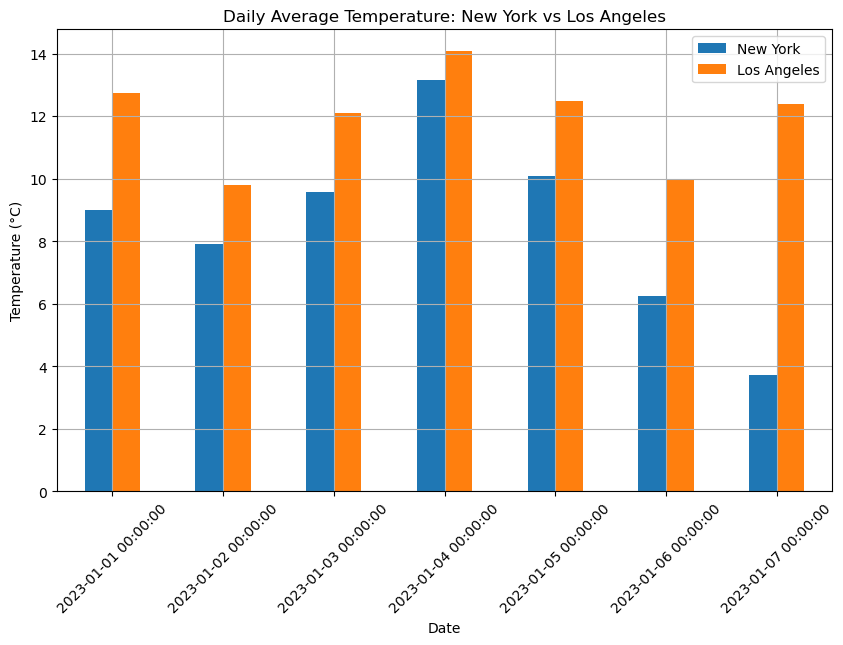

In [39]:
# Plot Comparison of Daily Average Temperature

combined_temp.plot(kind='bar', figsize=(10, 6))
plt.title('Daily Average Temperature: New York vs Los Angeles')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [40]:
# Step 9: Advanced Analysis - Temperature Difference

# Calculate Temperature Difference
combined_temp['Temp Difference'] = combined_temp['Los Angeles'] - combined_temp['New York']
combined_temp


,New York,Los Angeles,Temp Difference
time,,,
2023-01-01,9.008333,12.733333,3.725000
2023-01-02,7.916667,9.783333,1.866667
2023-01-03,9.575000,12.108333,2.533333
2023-01-04,13.154167,14.066667,0.912500
2023-01-05,10.070833,12.483333,2.412500
2023-01-06,6.233333,9.962500,3.729167
2023-01-07,3.737500,12.395833,8.658333


In [41]:
# Step 10: Save Data to CSV (Optional)

# Save New York data
df.to_csv('new_york_weather.csv')

# Save Los Angeles data
df_la.to_csv('los_angeles_weather.csv')


## Conclusion

In this exercise, we:

- Accessed and retrieved data from the **Open-Meteo API**.
- Cleaned and preprocessed JSON data using **pandas**.
- Performed exploratory data analysis and visualization.
- Compared weather patterns between **New York City** and **Los Angeles**.

---

**Next Steps**:

- **Extend the Date Range**: Analyze seasonal trends by fetching data over several months.
- **Fetch Additional Variables**: Include wind speed, atmospheric pressure, or other interesting variables.
- **Forecasting**: Use statistical methods or machine learning models to forecast future weather patterns.
- **Global Analysis**: Compare data from other global cities to gain broader insights.


## Exercises for Students

Now it's your turn! Below are some exercises to reinforce what you've learned. Try to complete them without looking at the solutions.

### Exercise: Compare Rainfall Between London and Seattle

- **Objective**: Compare the total weekly rainfall between London and Seattle over a full year.
- **Tasks**:
  1. **Fetch Data**: Retrieve hourly precipitation data for London and Seattle for the year 2022.
     - **London Coordinates**: Latitude `51.5074`, Longitude `-0.1278`
     - **Seattle Coordinates**: Latitude `47.6062`, Longitude `-122.3321`
  2. **Data Cleaning**: Convert the time columns to datetime objects and set them as the index. Handle any missing values.
  3. **Resample Data**: Resample the hourly data to weekly totals.
  4. **Visualization**: Plot the weekly total precipitation for both cities on the same graph.
  5. **Analysis**: Determine which city had more rainfall overall and identify any interesting patterns.

**Note**: Remember to handle any API limitations, such as data availability or rate limits, and to be mindful of the size of the data you're requesting.

### Tips:

- **API Parameters**: Make sure to adjust the parameters like `latitude`, `longitude`, `start_date`, `end_date`, `hourly`, and `timezone` as needed.
- **Error Handling**: Always check if your API requests are successful before proceeding.
- **Data Storage**: Consider saving your DataFrames to CSV files for future analysis.
- **Visualization**: Customize your plots with titles, labels, legends, and gridlines for better readability.

Happy coding!


In [62]:
#prepping params
london_lat = 51.5074
london_long = -0.1278
seattle_lat = 47.6062
seattle_long = -122.3321
new_sdate = '2022-01-01'
new_edate = '2022-12-31'
london_tz = 'Europe/London'
seattle_tz = 'America/Los_Angeles'
new_hourly_v = 'precipitation'

In [63]:
#put params in dict and request
lon_params = {'latitude':london_lat, 
              'longitude':london_long,
              'start_date':new_sdate,
              'end_date':new_edate,
              'hourly':new_hourly_v,
              'timezone':london_tz}

sea_params = {'latitude':seattle_lat, 
              'longitude':seattle_long,
              'start_date':new_sdate,
              'end_date':new_edate,
              'hourly':new_hourly_v,
              'timezone':seattle_tz}

lon_response = requests.get(base_url, params=lon_params)
sea_response = requests.get(base_url, params=sea_params)

In [64]:
#check if worked
if lon_response.status_code == 200:
    print('Data fetched successfully!')
else:
    print(f'Failed to fetch data. Status code: {lon_response.status_code}')


Data fetched successfully!


In [65]:
#check if worked
if sea_response.status_code == 200:
    print('Data fetched successfully!')
else:
    print(f'Failed to fetch data. Status code: {sea_response.status_code}')


Data fetched successfully!


In [70]:
# Make df
lon_data = lon_response.json()
lon_hourly_data = lon_data['hourly']
lon_df = pd.DataFrame(lon_hourly_data)
lon_df.head()

sea_data = sea_response.json()
sea_hourly_data = sea_data['hourly']
sea_df = pd.DataFrame(sea_hourly_data)
sea_df.head()

,time,precipitation
0,2022-01-01T00:00,0.0
1,2022-01-01T01:00,0.0
2,2022-01-01T02:00,0.0
3,2022-01-01T03:00,0.0
4,2022-01-01T04:00,0.0


In [71]:
#Clean data
#make dt
lon_df['time'] = pd.to_datetime(lon_df['time'])
sea_df['time'] = pd.to_datetime(sea_df['time'])

#set index astime
lon_df.set_index('time',inplace=True)
sea_df.set_index('time',inplace=True)

In [74]:
#check for missing values
sea_df.isnull().sum()
lon_df.isnull().sum()

precipitation    0
dtype: int64

In [76]:
lon_df.describe()

,precipitation
count,8760.000000
mean,0.075662
std,0.404500
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,14.700000


In [83]:
#resample data to weekly
lon_weekly = lon_df.resample('W').mean()
sea_weekly = sea_df.resample('W').mean()

In [84]:
#combine data into df
combined_prec = pd.DataFrame({'Seattle': sea_weekly['precipitation'],
                'London': lon_weekly['precipitation']})
combined_prec.head()


,Seattle,London
time,,
2022-01-02,0.652083,0.045833
2022-01-09,0.647619,0.076786
2022-01-16,0.270833,0.018452
2022-01-23,0.093452,0.000000
2022-01-30,0.036310,0.000595


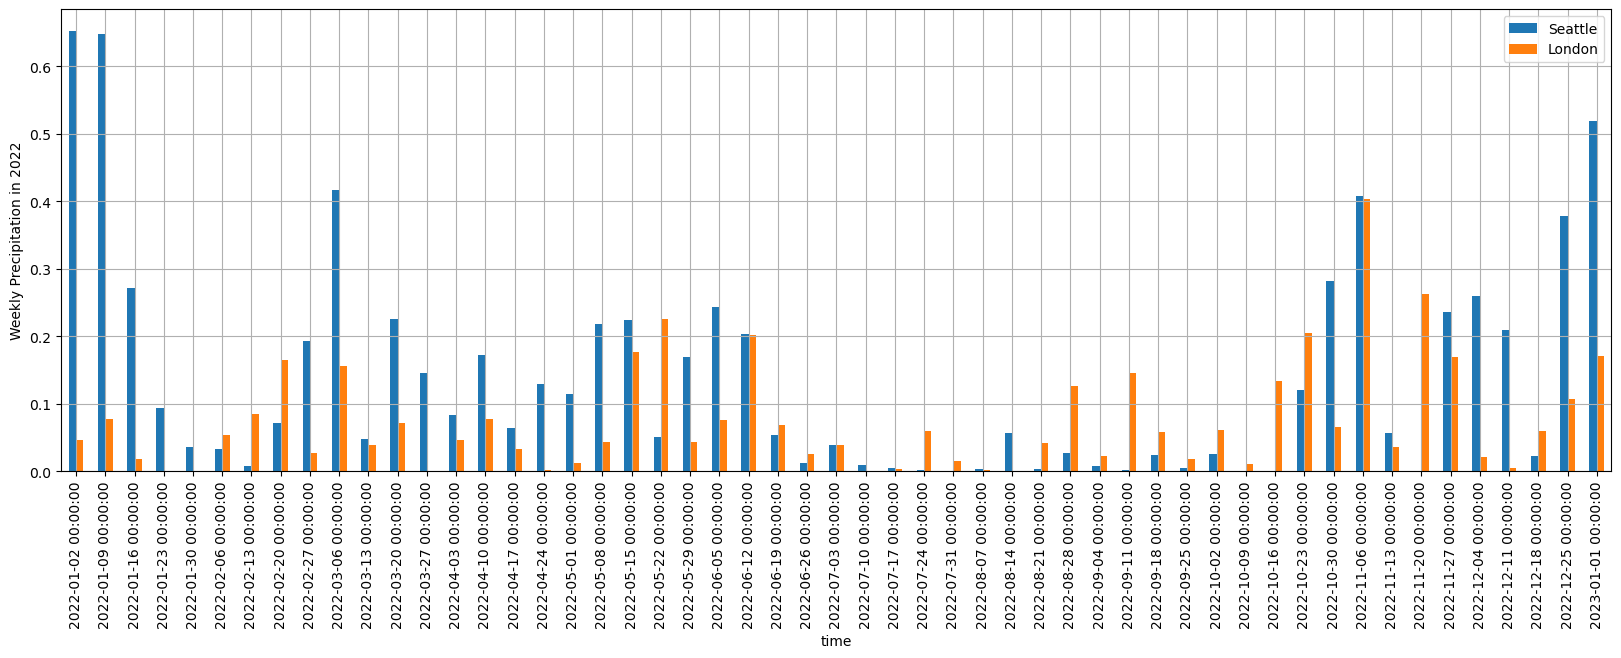

In [99]:
combined_prec.plot(kind='bar', figsize = (20,6))
plt.ylabel('Weekly Precipitation in 2022')
plt.grid(True)
plt.show()

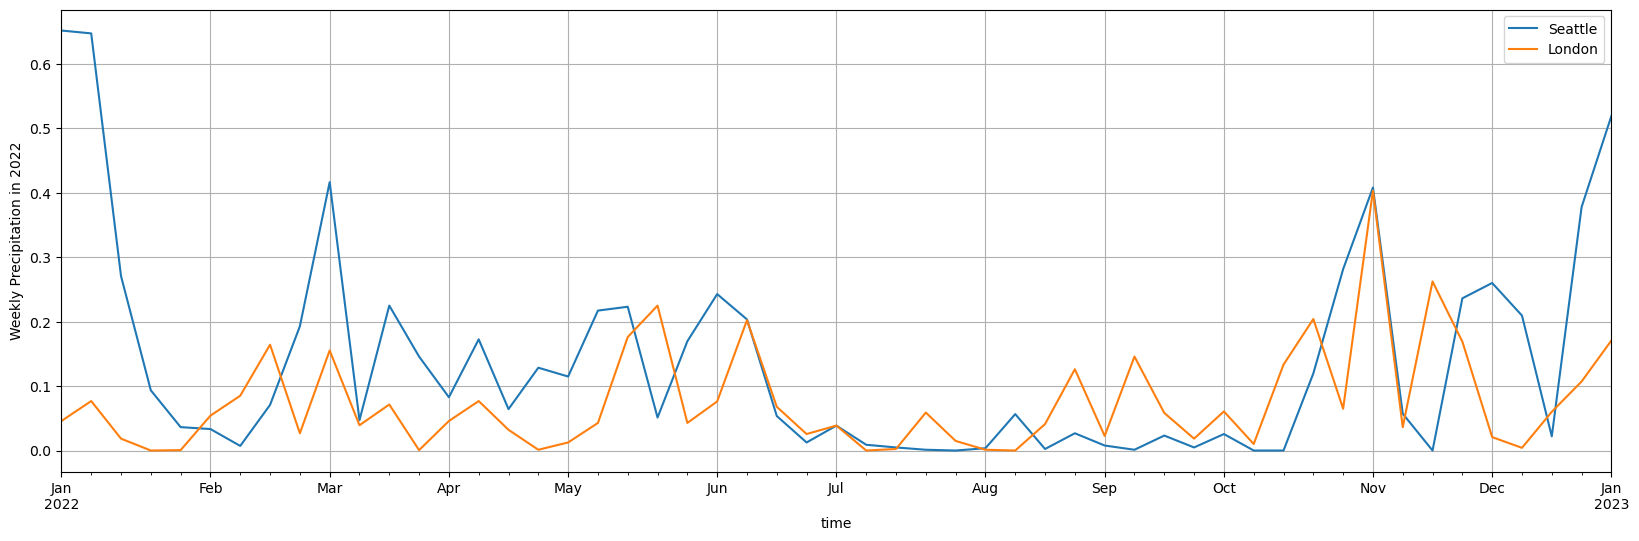

In [101]:
combined_prec.plot(kind='line', figsize = (20,6))
plt.ylabel('Weekly Precipitation in 2022')
plt.grid(True)
plt.show()

# Analysis:
Throughout most of 2022 we see that it rained more in Seattle than in London. Seattle in the monts of july- october significantly drops in the amount it rains, and it even rains less than London in those months. London is pretty consistent in the amount it rains but it does stll have a drop in those months as well.